# FOXF1_BMP4_timelapse — 01_qc_normalization

**Feeds:** Fig 5i, ED Fig 10f

**Position in the chain:** run the numbered notebooks in order

Ported unchanged from the original analysis: outputs are as they ran, and no code
cell was edited. Paths appear as `<analysis-root>/...`.


# FOXF1/BMP4 Timelapse: Step 1 QC + Flat-Field Calibration

This notebook now ends at flat-field estimation/validation and exports a handoff package for downstream segmentation/measurement.


In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Resolve project root robustly whether Jupyter cwd is project root or notebooks/
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
project_root = None
for cand in _candidates:
    if (cand / "scripts" / "qc_normalization_utils.py").exists():
        project_root = cand
        break
if project_root is None:
    raise RuntimeError(
        f"Could not locate project root containing scripts/qc_normalization_utils.py from cwd={_cwd}"
    )

scripts_dir = project_root / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

import qc_normalization_utils as qc

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
print("Project root:", project_root)

Project root: <analysis-root>/FOXF1_BMP4_timelapse


In [ ]:
# ---- Configuration ----
DATA_ROOT = (
    project_root
    / "data/20260213_2D_BMP4-reporter_LPMdiff_d0-d2/d1-d3"
)
RESULTS_DIR = project_root / "results/datasets/20260213/qc_normalization"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Handoff package for downstream segmentation notebook.
SEGMENTATION_HANDOFF_DIR = project_root / "results/datasets/20260213/segmentation_handoff"
SEGMENTATION_HANDOFF_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_SEGMENTATION_HANDOFF = True

# Quick mode is recommended for iterative inspection in Jupyter.
RUN_FULL = False

INDEX_TIME_STEP = 1
QC_SAMPLE_EVERY_N = 1 if RUN_FULL else 10
QC_MAX_FRAMES_PER_GROUP = None if RUN_FULL else 45
FLATFIELD_SAMPLE_N = 300 if RUN_FULL else 100
RANDOM_STATE = 0

print("DATA_ROOT:", DATA_ROOT)
print("RUN_FULL:", RUN_FULL)
print("QC_SAMPLE_EVERY_N:", QC_SAMPLE_EVERY_N)
print("FLATFIELD_SAMPLE_N:", FLATFIELD_SAMPLE_N)
print("SEGMENTATION_HANDOFF_DIR:", SEGMENTATION_HANDOFF_DIR)

DATA_ROOT: <analysis-root>/FOXF1_BMP4_timelapse/data/20260213_2D_BMP4-reporter_LPMdiff_d0-d2/d1-d3
RUN_FULL: False
QC_SAMPLE_EVERY_N: 10
FLATFIELD_SAMPLE_N: 100
SEGMENTATION_HANDOFF_DIR: <analysis-root>/FOXF1_BMP4_timelapse/results/datasets/20260213/segmentation_handoff


## 1) Load metadata and build image index

In [ ]:
position_dirs = qc.list_position_dirs(DATA_ROOT)
print(f"Found {len(position_dirs)} position folders")
if not position_dirs:
    raise RuntimeError(f"No position folders found under {DATA_ROOT}")

metadata = qc.load_experiment_metadata(position_dirs[0])
channel_names = qc.infer_channel_names(metadata)
summary = metadata["Summary"]

stage_df = qc.stage_positions_table(metadata)
index_df = qc.build_file_index(DATA_ROOT, time_step=INDEX_TIME_STEP)

print("Channel names:", channel_names)
print(
    "Frames:",
    summary.get("Frames"),
    "Channels:",
    summary.get("Channels"),
    "Slices:",
    summary.get("Slices"),
)
print("Interval (ms):", summary.get("Interval_ms"))
print("Indexed TIFF files:", len(index_df))

display(stage_df.head())
display(index_df.head())

Found 30 position folders
Channel names: {0: 'Phase', 1: 'RFP', 2: 'YFP'}
Frames: 300 Channels: 3 Slices: 1
Interval (ms): 600000.0
Indexed TIFF files: 27000


  position_label  row  col      x_um     y_um     z_um  grid_row_field  grid_col_field
0   1-Pos009_012    9   12 -103937.0 -64858.0  100.573               0               0
1   1-Pos010_012   10   12 -103429.0 -64858.0  101.767               0               0
2   1-Pos011_012   11   12 -102917.0 -64858.0   96.318               0               0
3   1-Pos012_012   12   12 -102408.0 -64858.0   96.007               0               0
4   1-Pos013_012   13   12 -101900.0 -64858.0   93.862               0               0

  position_label  row  col  file_position_index  channel  time  z                                               path
0   1-Pos009_012    9   12                    0        0     0  0  <analysis-root>/data_...
1   1-Pos009_012    9   12                    0        0     1  0  <analysis-root>/data_...
2   1-Pos009_012    9   12                    0        0     2  0  <analysis-root>/data_...
3   1-Pos009_012    9   12                    0        0     3  0  <analysis-root>/data_...
4   1-Pos009_012    9   12                    0        0     4  0  <analysis-root>/data_...

## 2) Completeness checks

In [ ]:
expected_channels = int(summary.get("Channels", 3))
expected_timepoints = int(summary.get("Frames", 300))
expected_z = int(summary.get("Slices", 1))

report = qc.completeness_report(
    index_df,
    expected_channels=expected_channels,
    expected_timepoints=expected_timepoints,
    expected_z=expected_z,
)
per_pos = report["per_position"]
per_pos_ch = report["per_position_channel"]
duplicates = report["duplicates"]

print(
    "Total expected files:",
    len(position_dirs) * expected_channels * expected_timepoints * expected_z,
)
print("Total observed files:", len(index_df))
print("Total missing files:", int(per_pos["missing_files"].sum()))
print("Duplicate entries:", len(duplicates))

display(per_pos.head())
display(per_pos_ch.head())
if len(duplicates) > 0:
    display(duplicates.head())

Total expected files: 27000
Total observed files: 27000
Total missing files: 0
Duplicate entries: 0


  position_label  row  col  observed_files  expected_files  missing_files
0   1-Pos009_012    9   12             900             900              0
1   1-Pos009_013    9   13             900             900              0
2   1-Pos009_014    9   14             900             900              0
3   1-Pos009_015    9   15             900             900              0
4   1-Pos009_016    9   16             900             900              0

  position_label  channel  n_unique_times  expected_times  missing_times
0   1-Pos009_012        0             300             300              0
1   1-Pos009_012        1             300             300              0
2   1-Pos009_012        2             300             300              0
3   1-Pos009_013        0             300             300              0
4   1-Pos009_013        1             300             300              0

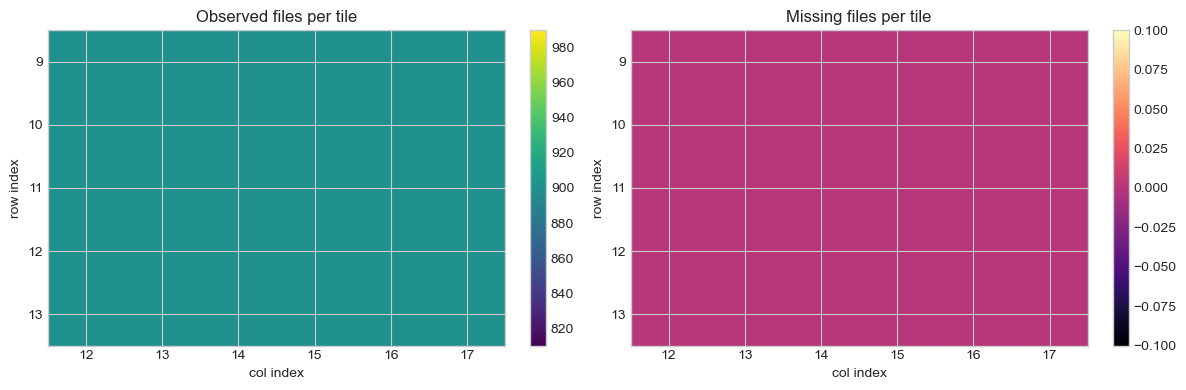

In [ ]:
# Visualize observed and missing file counts on the inferred tile grid.
obs_grid = (
    per_pos.pivot(index="row", columns="col", values="observed_files")
    .sort_index()
    .sort_index(axis=1)
)
miss_grid = (
    per_pos.pivot(index="row", columns="col", values="missing_files")
    .sort_index()
    .sort_index(axis=1)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(obs_grid.values, aspect="auto", cmap="viridis")
axes[0].set_title("Observed files per tile")
axes[0].set_xticks(range(obs_grid.shape[1]))
axes[0].set_xticklabels(obs_grid.columns)
axes[0].set_yticks(range(obs_grid.shape[0]))
axes[0].set_yticklabels(obs_grid.index)
axes[0].set_xlabel("col index")
axes[0].set_ylabel("row index")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(miss_grid.values, aspect="auto", cmap="magma")
axes[1].set_title("Missing files per tile")
axes[1].set_xticks(range(miss_grid.shape[1]))
axes[1].set_xticklabels(miss_grid.columns)
axes[1].set_yticks(range(miss_grid.shape[0]))
axes[1].set_yticklabels(miss_grid.index)
axes[1].set_xlabel("col index")
axes[1].set_ylabel("row index")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 3) Confirm tile geometry from stage metadata

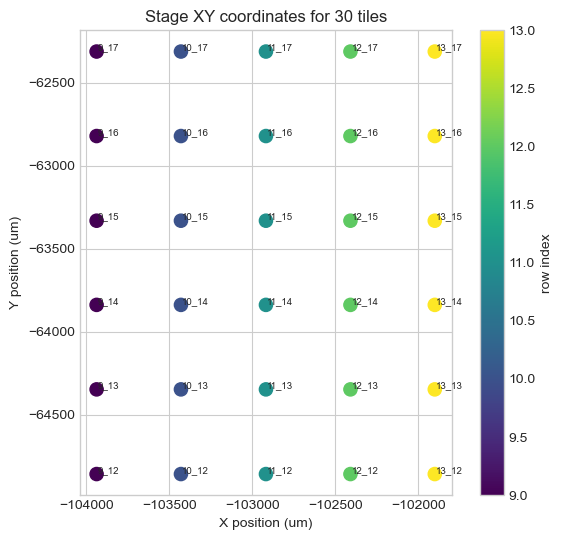

Median stage step in X (um): 508.5
Median stage step in Y (um): 509.0


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(
    stage_df["x_um"], stage_df["y_um"], c=stage_df["row"], s=90, cmap="viridis"
)
for r in stage_df.itertuples(index=False):
    ax.text(r.x_um + 7, r.y_um + 7, f"{int(r.row)}_{int(r.col)}", fontsize=7)
ax.set_title("Stage XY coordinates for 30 tiles")
ax.set_xlabel("X position (um)")
ax.set_ylabel("Y position (um)")
ax.set_aspect("equal")
cb = fig.colorbar(sc, ax=ax, fraction=0.046)
cb.set_label("row index")
plt.tight_layout()
plt.show()

x_steps = stage_df.sort_values(["col", "row"]).groupby("col")["x_um"].diff().dropna()
y_steps = stage_df.sort_values(["row", "col"]).groupby("row")["y_um"].diff().dropna()
print("Median stage step in X (um):", float(np.median(x_steps)))
print("Median stage step in Y (um):", float(np.median(y_steps)))

## 4) Frame-level QC metrics (sampled)

This computes per-frame scalar metrics on sampled frames:

- Intensity: min/max/mean/median/std, p01/p99
- Saturation: fraction at 0 and 65535
- Focus proxy (channel 0 by default): Laplacian variance


In [ ]:
frame_qc_df = qc.compute_frame_metrics(
    index_df,
    channels=(0, 1, 2),
    sample_every_n=QC_SAMPLE_EVERY_N,
    max_frames_per_group=QC_MAX_FRAMES_PER_GROUP,
    focus_channels=(0,),
    progress_every=500,
)
frame_qc_df["minutes"] = frame_qc_df["time"] * (
    summary.get("Interval_ms", 600000) / 1000 / 60
)
frame_qc_df["hours"] = frame_qc_df["minutes"] / 60
frame_qc_df["channel_name"] = (
    frame_qc_df["channel"].map(channel_names).fillna(frame_qc_df["channel"].astype(str))
)

print("Sampled QC rows:", len(frame_qc_df))
display(frame_qc_df.head())

display(
    frame_qc_df.groupby(["channel", "channel_name"])[
        ["mean", "p99", "sat_zero_frac", "sat_max_frac", "lap_var"]
    ].agg(["median", "mean"])
)

Computed frame metrics for 500/2700 sampled frames
Computed frame metrics for 1000/2700 sampled frames
Computed frame metrics for 1500/2700 sampled frames
Computed frame metrics for 2000/2700 sampled frames
Computed frame metrics for 2500/2700 sampled frames
Computed frame metrics for 2700/2700 sampled frames
Sampled QC rows: 2700


      min      max          mean   median         std       p01      p99  sat_zero_frac  sat_max_frac       lap_var position_label  row  col  file_position_index  channel  time  \
0  9092.0  19105.0  16166.157227  16399.0  953.777771  12127.00  17291.0            0.0           0.0  263997.03125   1-Pos009_012    9   12                    0        0     0   
1  8748.0  20068.0  16162.934570  16394.0  959.502075  12139.43  17315.0            0.0           0.0  276796.75000   1-Pos009_012    9   12                    0        0    10   
2  9301.0  21925.0  16158.784180  16400.0  971.174316  12137.00  17385.0            0.0           0.0  304287.15625   1-Pos009_012    9   12                    0        0    20   
3  9354.0  20963.0  16184.723633  16431.0  972.062500  12146.43  17434.0            0.0           0.0  290366.12500   1-Pos009_012    9   12                    0        0    30   
4  9276.0  24133.0  16170.976562  16401.0  973.712646  12051.43  17442.0            0.0           0.

                              mean                    p99               sat_zero_frac      sat_max_frac            lap_var               
                            median          mean   median          mean        median mean       median mean        median           mean
channel channel_name                                                                                                                     
0       Phase         14561.903809  14588.214635  15710.5  15688.359067           0.0  0.0          0.0  0.0  284028.03125  281328.123576
1       RFP            2164.781616   2164.743318   2256.0   2270.657433           0.0  0.0          0.0  0.0           NaN            NaN
2       YFP            3182.532593   3221.974087   3376.0   3412.531100           0.0  0.0          0.0  0.0           NaN            NaN

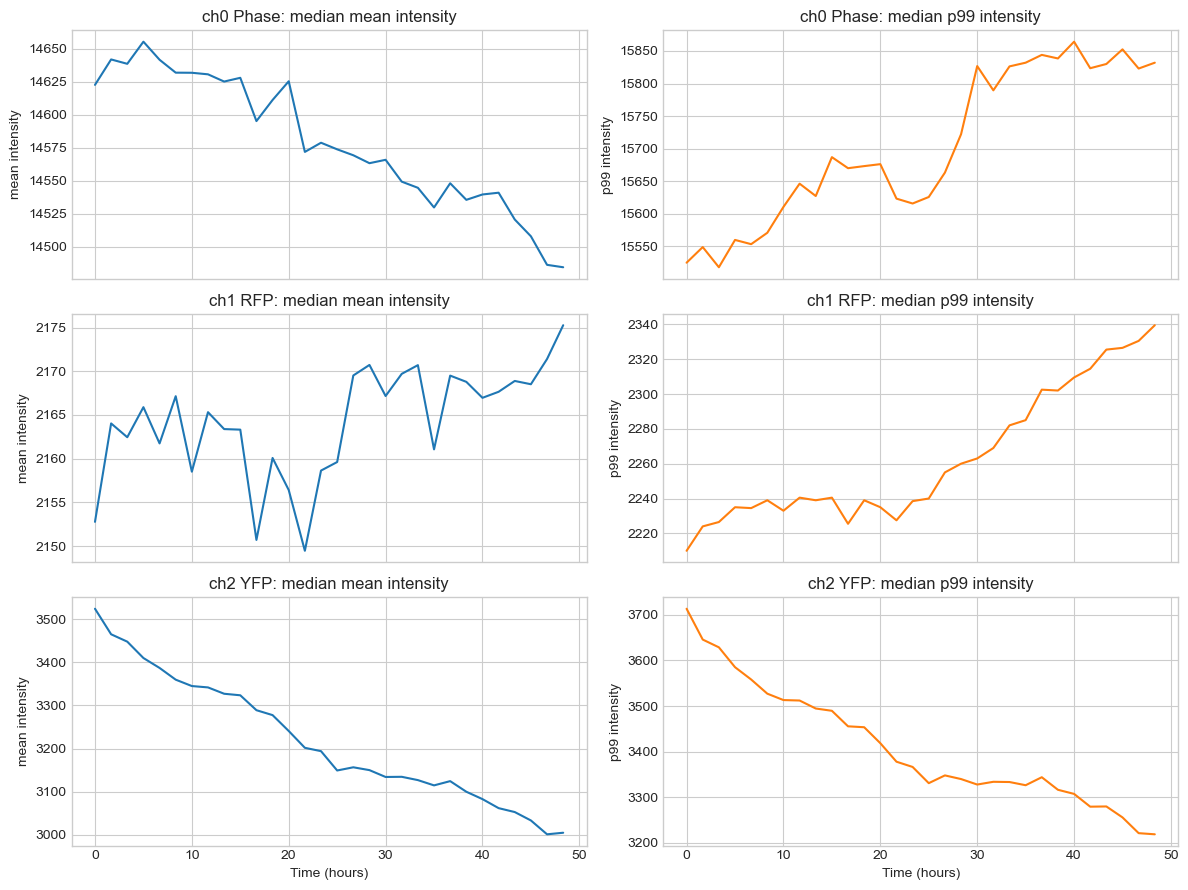

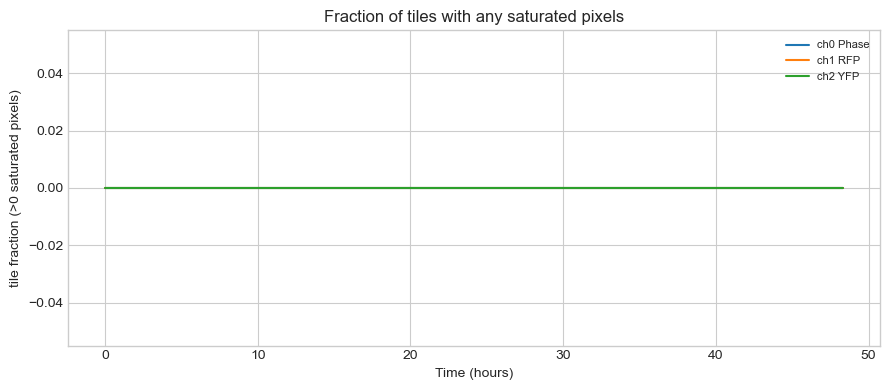

   channel  max_tile_fraction_with_saturation  max_saturated_pixel_fraction_any_tile channel_name
0        0                                0.0                                    0.0        Phase
1        1                                0.0                                    0.0          RFP
2        2                                0.0                                    0.0          YFP

In [ ]:
# Aggregate trends over time (median across positions)
agg = frame_qc_df.groupby(["channel", "time"], as_index=False).agg(
    mean_median=("mean", "median"),
    p99_median=("p99", "median"),
    satmax_median=("sat_max_frac", "median"),
    satmax_q95=("sat_max_frac", lambda x: float(np.percentile(x, 95))),
    satmax_q99=("sat_max_frac", lambda x: float(np.percentile(x, 99))),
    satmax_max=("sat_max_frac", "max"),
    satmax_any_frac=("sat_max_frac", lambda x: float(np.mean(np.array(x) > 0))),
)
agg["hours"] = agg["time"] * (summary.get("Interval_ms", 600000) / 1000 / 3600)

channels_sorted = sorted(agg["channel"].unique())

# Intensity plots: separate panel per channel to avoid scale compression.
fig, axes = plt.subplots(
    len(channels_sorted), 2, figsize=(12, 3.0 * len(channels_sorted)), sharex=True
)
if len(channels_sorted) == 1:
    axes = np.array([axes])

for i, ch in enumerate(channels_sorted):
    d = agg[agg["channel"] == ch]
    label = channel_names.get(int(ch), str(ch))

    axes[i, 0].plot(d["hours"], d["mean_median"], color="tab:blue")
    axes[i, 0].set_title(f"ch{ch} {label}: median mean intensity")
    axes[i, 0].set_ylabel("mean intensity")

    axes[i, 1].plot(d["hours"], d["p99_median"], color="tab:orange")
    axes[i, 1].set_title(f"ch{ch} {label}: median p99 intensity")
    axes[i, 1].set_ylabel("p99 intensity")

for ax in axes[-1, :]:
    ax.set_xlabel("Time (hours)")

plt.tight_layout()
plt.show()

# Clipping check: fraction of tiles with any saturated pixels (>0) at each time.
fig, ax = plt.subplots(figsize=(9, 4))
for ch in channels_sorted:
    d = agg[agg["channel"] == ch]
    label = channel_names.get(int(ch), str(ch))
    ax.plot(d["hours"], d["satmax_any_frac"], label=f"ch{ch} {label}")

ax.set_title("Fraction of tiles with any saturated pixels")
ax.set_ylabel("tile fraction (>0 saturated pixels)")
ax.set_xlabel("Time (hours)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Optional numeric summary for quick reporting.
sat_summary = agg.groupby("channel", as_index=False).agg(
    max_tile_fraction_with_saturation=("satmax_any_frac", "max"),
    max_saturated_pixel_fraction_any_tile=("satmax_max", "max"),
)
sat_summary["channel_name"] = (
    sat_summary["channel"].map(channel_names).fillna(sat_summary["channel"].astype(str))
)
display(sat_summary)

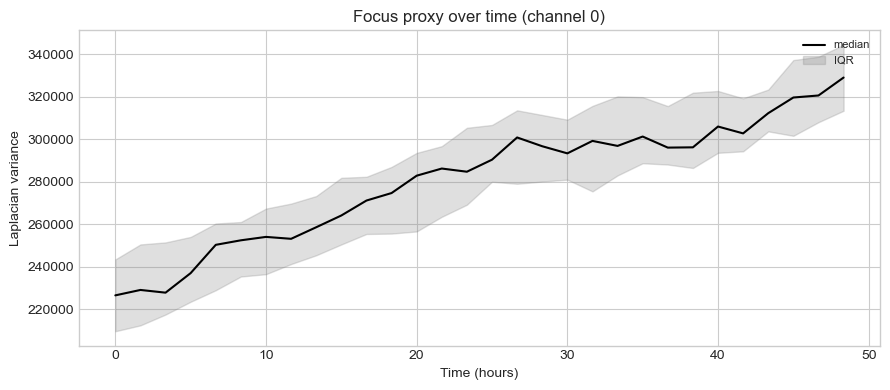

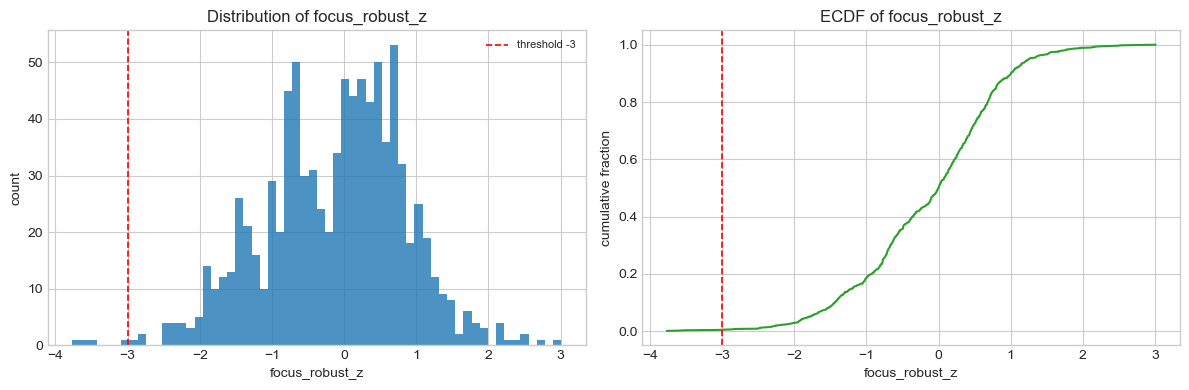

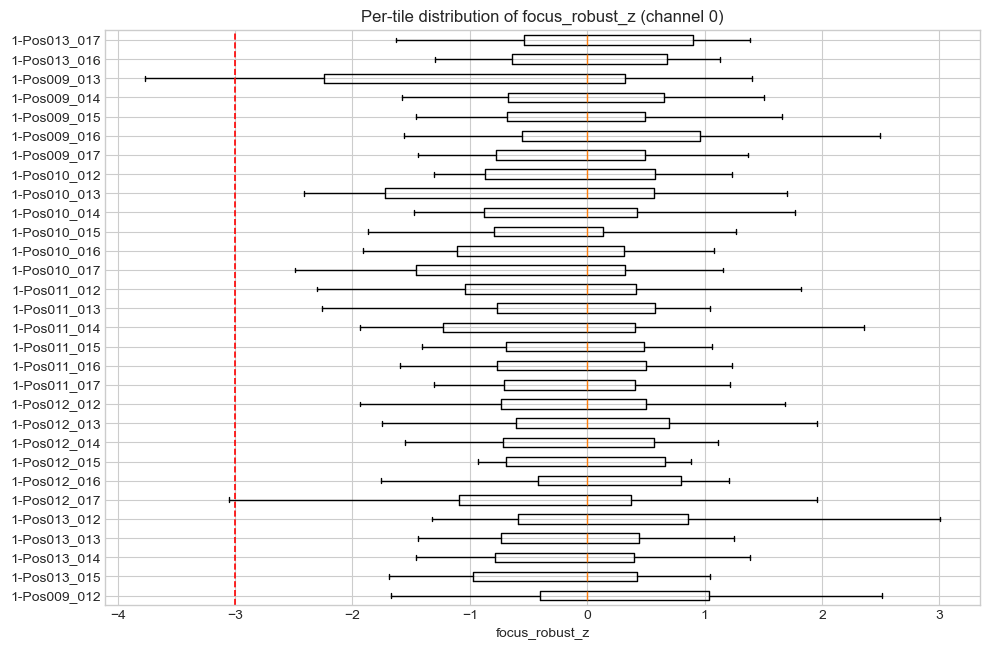

Low-focus events (robust z < -3): 4


     position_label  time        lap_var  focus_robust_z                                               path
90     1-Pos009_013     0  254607.515625       -3.583944  <analysis-root>/data_...
91     1-Pos009_013    10  252121.093750       -3.765367  <analysis-root>/data_...
92     1-Pos009_013    20  255514.156250       -3.517791  <analysis-root>/data_...
2071   1-Pos012_017    10  205377.703125       -3.054493  <analysis-root>/data_...

Worst tiles by minimum robust z (lower = blurrier events):


   position_label     z_min  z_median     z_q25     z_q75  n_low
27   1-Pos009_013 -3.765367       0.0 -2.241778  0.324634      3
5    1-Pos012_017 -3.054493       0.0 -1.092164  0.374650      1
17   1-Pos010_017 -2.491167       0.0 -1.457293  0.321339      0
21   1-Pos010_013 -2.408797       0.0 -1.723706  0.572747      0
16   1-Pos011_012 -2.302435       0.0 -1.044578  0.419022      0
15   1-Pos011_013 -2.256654       0.0 -0.772439  0.580882      0
14   1-Pos011_014 -1.937786       0.0 -1.228176  0.408842      0
10   1-Pos012_012 -1.937607       0.0 -0.737325  0.502930      0
18   1-Pos010_016 -1.913183       0.0 -1.109822  0.315342      0
19   1-Pos010_015 -1.866980       0.0 -0.790527  0.138656      0

In [ ]:
# Focus stability (channel 0 only): trends + distributions
focus_df = frame_qc_df[frame_qc_df["channel"] == 0].copy()
if focus_df.empty:
    print("No channel 0 rows found in frame_qc_df")
else:
    focus_agg = focus_df.groupby("time", as_index=False).agg(
        lap_var_median=("lap_var", "median"),
        lap_var_q25=("lap_var", lambda x: float(np.percentile(x, 25))),
        lap_var_q75=("lap_var", lambda x: float(np.percentile(x, 75))),
    )
    focus_agg["hours"] = focus_agg["time"] * (
        summary.get("Interval_ms", 600000) / 1000 / 3600
    )

    def robust_z(x):
        med = np.median(x)
        mad = np.median(np.abs(x - med))
        return (x - med) / (1.4826 * mad + 1e-6)

    focus_df["focus_robust_z"] = focus_df.groupby("position_label")[
        "lap_var"
    ].transform(robust_z)

    # 1) Time trend with IQR band.
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(
        focus_agg["hours"], focus_agg["lap_var_median"], color="black", label="median"
    )
    ax.fill_between(
        focus_agg["hours"],
        focus_agg["lap_var_q25"],
        focus_agg["lap_var_q75"],
        color="gray",
        alpha=0.25,
        label="IQR",
    )
    ax.set_title("Focus proxy over time (channel 0)")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Laplacian variance")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # 2) Distribution of robust z-scores (all tiles x sampled frames).
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(focus_df["focus_robust_z"], bins=60, color="tab:blue", alpha=0.8)
    axes[0].axvline(
        -3, color="red", linestyle="--", linewidth=1.2, label="threshold -3"
    )
    axes[0].set_title("Distribution of focus_robust_z")
    axes[0].set_xlabel("focus_robust_z")
    axes[0].set_ylabel("count")
    axes[0].legend(fontsize=8)

    z_sorted = np.sort(focus_df["focus_robust_z"].values)
    y = np.arange(1, len(z_sorted) + 1) / len(z_sorted)
    axes[1].plot(z_sorted, y, color="tab:green")
    axes[1].axvline(-3, color="red", linestyle="--", linewidth=1.2)
    axes[1].set_title("ECDF of focus_robust_z")
    axes[1].set_xlabel("focus_robust_z")
    axes[1].set_ylabel("cumulative fraction")

    plt.tight_layout()
    plt.show()

    # 3) Per-tile distribution via horizontal boxplots.
    pos_stats = focus_df.groupby("position_label", as_index=False).agg(
        z_min=("focus_robust_z", "min"),
        z_median=("focus_robust_z", "median"),
        z_q25=("focus_robust_z", lambda x: float(np.percentile(x, 25))),
        z_q75=("focus_robust_z", lambda x: float(np.percentile(x, 75))),
        n_low=("focus_robust_z", lambda x: int(np.sum(np.array(x) < -3))),
    )
    pos_stats = pos_stats.sort_values("z_median").reset_index(drop=True)

    ordered = pos_stats["position_label"].tolist()
    data = [
        focus_df.loc[focus_df["position_label"] == p, "focus_robust_z"].values
        for p in ordered
    ]

    fig, ax = plt.subplots(figsize=(10, max(6, 0.22 * len(ordered))))
    ax.boxplot(data, vert=False, labels=ordered, showfliers=False)
    ax.axvline(-3, color="red", linestyle="--", linewidth=1.2)
    ax.set_title("Per-tile distribution of focus_robust_z (channel 0)")
    ax.set_xlabel("focus_robust_z")
    plt.tight_layout()
    plt.show()

    # Also list specific outlier frames (as in the original version).
    low_focus_events = focus_df[focus_df["focus_robust_z"] < -3].sort_values(
        ["position_label", "time"]
    )
    print("Low-focus events (robust z < -3):", len(low_focus_events))
    if len(low_focus_events) > 0:
        display(
            low_focus_events[
                ["position_label", "time", "lap_var", "focus_robust_z", "path"]
            ].head(50)
        )

    # Keep a compact summary instead of only listing raw outlier rows.
    print("Worst tiles by minimum robust z (lower = blurrier events):")
    display(pos_stats.sort_values(["z_min", "n_low"]).head(10))

## 5) Build flat-field estimates for fluorescence channels

Estimating flat-field for channel 1 (RFP) ...
Estimating flat-field for channel 2 (YFP) ...


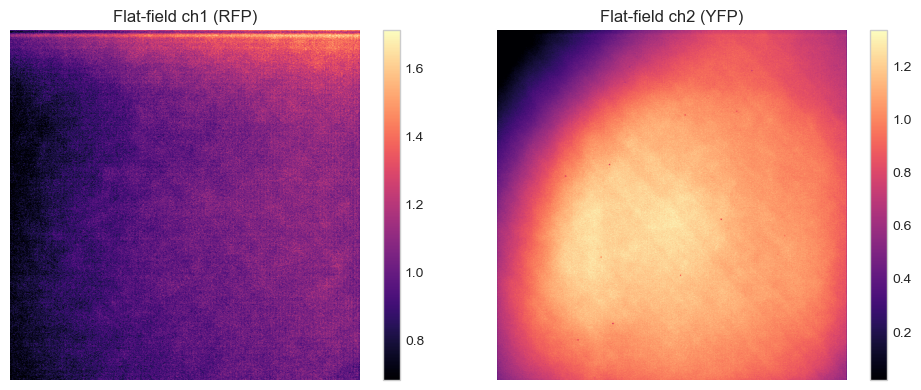

In [ ]:
flatfields = {}
for ch in (1, 2):
    print(f"Estimating flat-field for channel {ch} ({channel_names.get(ch, ch)}) ...")
    flatfields[ch] = qc.estimate_flatfield(
        index_df,
        channel=ch,
        sample_n=FLATFIELD_SAMPLE_N,
        random_state=RANDOM_STATE,
        background_percentile=1.0,
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ch in enumerate((1, 2)):
    ff = flatfields[ch]
    im = axes[i].imshow(ff, cmap="magma")
    axes[i].set_title(f"Flat-field ch{ch} ({channel_names.get(ch, ch)})")
    axes[i].set_axis_off()
    fig.colorbar(im, ax=axes[i], fraction=0.046)

plt.tight_layout()
plt.show()

## 5b) Validate flat-field correction (holdout frames)

This cross-check tests whether flat-field correction removes low-frequency shading without obvious over-correction.

For each channel, it reports before/after on holdout frames:

- `lowfreq_cv`: spatial nonuniformity in a Gaussian-smoothed image (lower is better)
- `center_edge_ratio`: center brightness / edge brightness (should move toward 1)
- `pearson_r_lowfreq_vs_ff`: Pearson correlation between low-frequency image and flat-field map (should move toward 0)

Interpretation guide:

- Good correction: `lowfreq_cv` decreases, `center_edge_ratio` moves toward 1, and correlation drops strongly from raw.
- Potential over-correction: correlation becomes strongly negative for many frames.


Validating flat-field for channel 1 (RFP) ...
Validating flat-field for channel 2 (YFP) ...


   channel channel_name  n_train  n_test  lowfreq_cv_raw_med  lowfreq_cv_corrected_med  lowfreq_cv_delta_med  center_edge_raw_med  center_edge_corrected_med  \
0        1          RFP      180     180            0.128140                  0.055682             -0.071167             1.004051                   1.007550   
1        2          YFP      180     180            0.181443                  0.031213             -0.151707             1.317253                   0.990687   

   center_edge_absdist_to1_raw_med  center_edge_absdist_to1_corrected_med  pearson_r_lowfreq_vs_ff_raw_med  pearson_r_lowfreq_vs_ff_corrected_med  \
0                         0.022914                               0.025175                         0.861267                              -0.020491   
1                         0.317253                               0.010589                         0.988172                              -0.469066   

   pearson_r_lowfreq_vs_ff_corrected_q05  pearson_r_lowfreq_vs_ff_corre

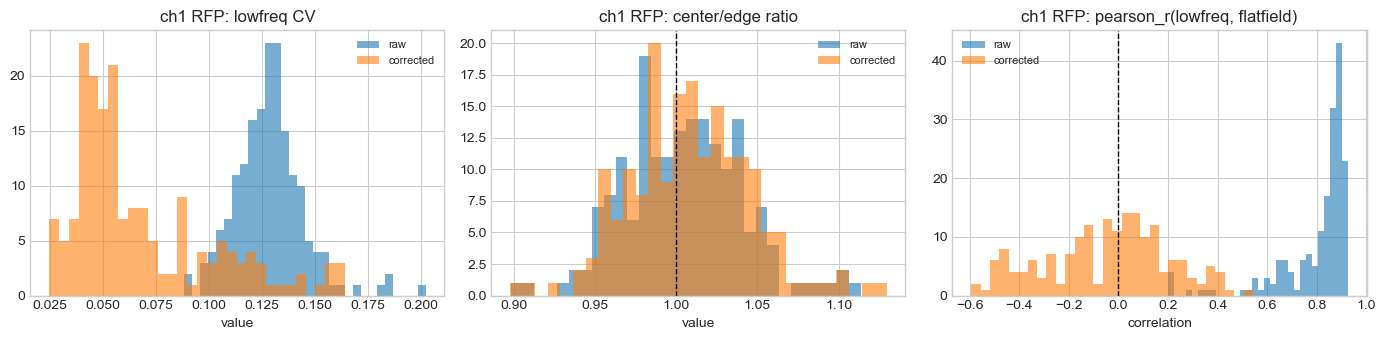

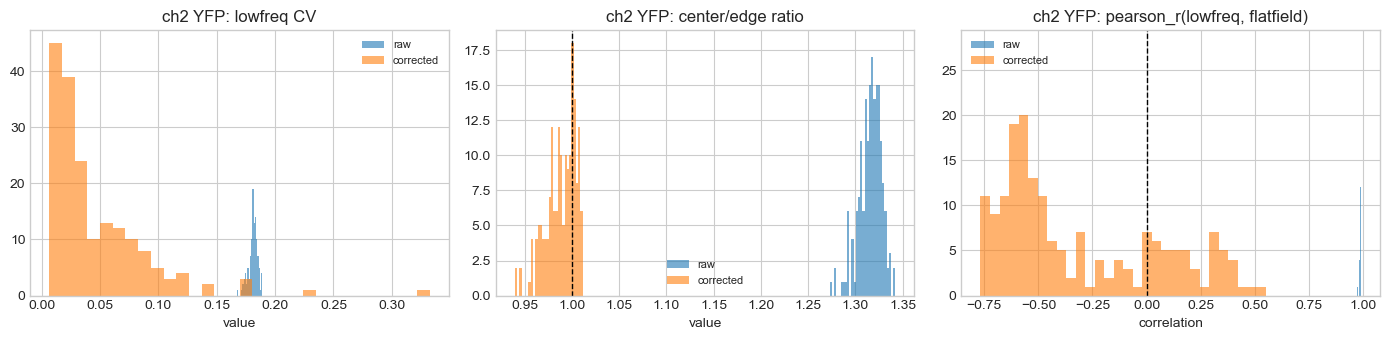

In [ ]:
import cv2

VALIDATE_CHANNELS = (1, 2)  # set to (1,) if you only want RFP
VAL_N_TRAIN = 180
VAL_N_TEST = 180
VAL_BG_PERCENTILE = 1.0
VAL_SIGMA = 35
VAL_CENTER_FRAC = 0.5
VAL_RANDOM_STATE = 7


def _lowfreq(img, sigma=35):
    return cv2.GaussianBlur(img.astype(np.float32), (0, 0), sigmaX=sigma, sigmaY=sigma)


def _edge_center_masks(shape, center_frac=0.5):
    h, w = shape
    yy, xx = np.mgrid[0:h, 0:w]
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    ry, rx = h * center_frac / 2.0, w * center_frac / 2.0
    center = (np.abs(yy - cy) <= ry) & (np.abs(xx - cx) <= rx)
    edge = ~center
    return edge, center


def _frame_validation_metrics(bgsub, ff_corrected, ff, sigma=35, center_frac=0.5):
    # Normalize per frame to isolate spatial pattern (not global brightness level).
    b = bgsub / (np.median(bgsub) + 1e-6)
    c = ff_corrected / (np.median(ff_corrected) + 1e-6)

    lf_b = _lowfreq(b, sigma=sigma)
    lf_c = _lowfreq(c, sigma=sigma)

    # Ignore darkest 5% of low-frequency pixels to stabilize metrics.
    m_b = lf_b > np.percentile(lf_b, 5)
    m_c = lf_c > np.percentile(lf_c, 5)

    cv_b = float(lf_b[m_b].std() / (lf_b[m_b].mean() + 1e-6))
    cv_c = float(lf_c[m_c].std() / (lf_c[m_c].mean() + 1e-6))

    edge, center = _edge_center_masks(lf_b.shape, center_frac=center_frac)
    center_edge_b = float(lf_b[center].mean() / (lf_b[edge].mean() + 1e-6))
    center_edge_c = float(lf_c[center].mean() / (lf_c[edge].mean() + 1e-6))

    ff_n = ff / (np.median(ff) + 1e-6)
    pearson_r_raw_ff = float(np.corrcoef(lf_b.ravel(), ff_n.ravel())[0, 1])
    pearson_r_corrected_ff = float(np.corrcoef(lf_c.ravel(), ff_n.ravel())[0, 1])

    return {
        "lowfreq_cv_raw": cv_b,
        "lowfreq_cv_corrected": cv_c,
        "center_edge_raw": center_edge_b,
        "center_edge_corrected": center_edge_c,
        "pearson_r_lowfreq_vs_ff_raw": pearson_r_raw_ff,
        "pearson_r_lowfreq_vs_ff_corrected": pearson_r_corrected_ff,
    }


def validate_flatfield_channel(
    index_df, channel, n_train=180, n_test=180, random_state=7
):
    df_ch = index_df[index_df["channel"] == channel].copy().reset_index(drop=True)
    if df_ch.empty:
        raise ValueError(f"No frames found for channel {channel}")

    n_train = min(n_train, len(df_ch) // 2)
    n_test = min(n_test, len(df_ch) - n_train)

    rng = np.random.default_rng(random_state)
    perm = rng.permutation(len(df_ch))
    train_idx = perm[:n_train]
    test_idx = perm[n_train : n_train + n_test]

    ff = qc.estimate_flatfield(
        df_ch.iloc[train_idx],
        channel=channel,
        sample_n=n_train,
        random_state=random_state,
        background_percentile=VAL_BG_PERCENTILE,
    )

    rows = []
    for i in test_idx:
        r = df_ch.iloc[i]
        raw = qc.read_tiff(r.path).astype(np.float32)
        bg = np.percentile(raw, VAL_BG_PERCENTILE)
        bgsub = np.clip(raw - bg, 0, None)
        ff_corrected = bgsub / np.clip(ff, 1e-6, None)

        m = _frame_validation_metrics(
            bgsub, ff_corrected, ff, sigma=VAL_SIGMA, center_frac=VAL_CENTER_FRAC
        )
        m.update(
            {
                "channel": channel,
                "position_label": r.position_label,
                "time": int(r.time),
            }
        )
        rows.append(m)

    metrics_df = pd.DataFrame(rows)

    summary = {
        "channel": channel,
        "channel_name": channel_names.get(channel, str(channel)),
        "n_train": n_train,
        "n_test": n_test,
        "lowfreq_cv_raw_med": float(metrics_df["lowfreq_cv_raw"].median()),
        "lowfreq_cv_corrected_med": float(metrics_df["lowfreq_cv_corrected"].median()),
        "lowfreq_cv_delta_med": float(
            (metrics_df["lowfreq_cv_corrected"] - metrics_df["lowfreq_cv_raw"]).median()
        ),
        "center_edge_raw_med": float(metrics_df["center_edge_raw"].median()),
        "center_edge_corrected_med": float(
            metrics_df["center_edge_corrected"].median()
        ),
        "center_edge_absdist_to1_raw_med": float(
            (metrics_df["center_edge_raw"] - 1).abs().median()
        ),
        "center_edge_absdist_to1_corrected_med": float(
            (metrics_df["center_edge_corrected"] - 1).abs().median()
        ),
        "pearson_r_lowfreq_vs_ff_raw_med": float(
            metrics_df["pearson_r_lowfreq_vs_ff_raw"].median()
        ),
        "pearson_r_lowfreq_vs_ff_corrected_med": float(
            metrics_df["pearson_r_lowfreq_vs_ff_corrected"].median()
        ),
        "pearson_r_lowfreq_vs_ff_corrected_q05": float(
            np.percentile(metrics_df["pearson_r_lowfreq_vs_ff_corrected"], 5)
        ),
        "pearson_r_lowfreq_vs_ff_corrected_q95": float(
            np.percentile(metrics_df["pearson_r_lowfreq_vs_ff_corrected"], 95)
        ),
    }

    return ff, metrics_df, summary


val_summaries = []
val_metrics = {}
val_ffs = {}

for ch in VALIDATE_CHANNELS:
    print(f"Validating flat-field for channel {ch} ({channel_names.get(ch, ch)}) ...")
    ff, mdf, smry = validate_flatfield_channel(
        index_df,
        channel=ch,
        n_train=VAL_N_TRAIN,
        n_test=VAL_N_TEST,
        random_state=VAL_RANDOM_STATE + int(ch),
    )
    val_ffs[ch] = ff
    val_metrics[ch] = mdf
    val_summaries.append(smry)

val_summary_df = (
    pd.DataFrame(val_summaries).sort_values("channel").reset_index(drop=True)
)
display(val_summary_df)

# Visual: metric distributions before vs after for each channel.
for ch in VALIDATE_CHANNELS:
    mdf = val_metrics[ch]
    label = channel_names.get(ch, str(ch))

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    axes[0].hist(mdf["lowfreq_cv_raw"], bins=30, alpha=0.6, label="raw")
    axes[0].hist(mdf["lowfreq_cv_corrected"], bins=30, alpha=0.6, label="corrected")
    axes[0].set_title(f"ch{ch} {label}: lowfreq CV")
    axes[0].set_xlabel("value")
    axes[0].legend(fontsize=8)

    axes[1].hist(mdf["center_edge_raw"], bins=30, alpha=0.6, label="raw")
    axes[1].hist(mdf["center_edge_corrected"], bins=30, alpha=0.6, label="corrected")
    axes[1].axvline(1.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title(f"ch{ch} {label}: center/edge ratio")
    axes[1].set_xlabel("value")
    axes[1].legend(fontsize=8)

    axes[2].hist(mdf["pearson_r_lowfreq_vs_ff_raw"], bins=30, alpha=0.6, label="raw")
    axes[2].hist(
        mdf["pearson_r_lowfreq_vs_ff_corrected"], bins=30, alpha=0.6, label="corrected"
    )
    axes[2].axvline(0.0, color="black", linestyle="--", linewidth=1)
    axes[2].set_title(f"ch{ch} {label}: pearson_r(lowfreq, flatfield)")
    axes[2].set_xlabel("correlation")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 6) Export Flat-Field Handoff For Segmentation

This writes the file index, stage layout, metadata summary, and flat-field arrays for use in `02_segmentation_setup.ipynb`.


In [ ]:
handoff_files = {}

if EXPORT_SEGMENTATION_HANDOFF:
    index_path = SEGMENTATION_HANDOFF_DIR / "index_df.csv"
    stage_path = SEGMENTATION_HANDOFF_DIR / "stage_positions.csv"
    summary_path = SEGMENTATION_HANDOFF_DIR / "metadata_summary.json"
    channels_path = SEGMENTATION_HANDOFF_DIR / "channel_names.json"
    flatfield_path = SEGMENTATION_HANDOFF_DIR / "flatfields.npz"

    index_df.to_csv(index_path, index=False)
    stage_df.to_csv(stage_path, index=False)

    summary_path.write_text(json.dumps(summary, indent=2))
    channels_path.write_text(json.dumps(channel_names, indent=2))

    np.savez_compressed(
        flatfield_path,
        ch1=flatfields[1].astype(np.float32),
        ch2=flatfields[2].astype(np.float32),
    )

    manifest = {
        "data_root": str(DATA_ROOT),
        "run_full": bool(RUN_FULL),
        "index_time_step": int(INDEX_TIME_STEP),
        "qc_sample_every_n": int(QC_SAMPLE_EVERY_N),
        "flatfield_sample_n": int(FLATFIELD_SAMPLE_N),
        "flatfield_background_percentile": 1.0,
        "channels_flatfielded": [1, 2],
        "files": {
            "index_df": str(index_path),
            "stage_positions": str(stage_path),
            "metadata_summary": str(summary_path),
            "channel_names": str(channels_path),
            "flatfields_npz": str(flatfield_path),
        },
    }
    manifest_path = SEGMENTATION_HANDOFF_DIR / "handoff_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2))

    handoff_files = manifest["files"]
    handoff_files["manifest"] = str(manifest_path)

    print("Exported segmentation handoff to", SEGMENTATION_HANDOFF_DIR)
    display(pd.Series(handoff_files, name="path").to_frame())
else:
    print("EXPORT_SEGMENTATION_HANDOFF is False. No handoff files written.")

Exported segmentation handoff to <analysis-root>/FOXF1_BMP4_timelapse/results/datasets/20260213/segmentation_handoff


                                                               path
index_df          <analysis-root>/data_...
stage_positions   <analysis-root>/data_...
metadata_summary  <analysis-root>/data_...
channel_names     <analysis-root>/data_...
flatfields_npz    <analysis-root>/data_...
manifest          <analysis-root>/data_...

## Notes

- This notebook now focuses on dataset QC and flat-field calibration only.
- Downstream segmentation and per-cell fluorescence extraction continue in `02_segmentation_setup.ipynb`.
- No time-dependent/post-flat background subtraction is applied in this notebook.
